<table style="border-collapse: collapse; border: none;">
  <tr>
    <td style="vertical-align: top; border: none;">
      <img src="https://i.imgur.com/x6poGzn.png" width="130" height="170" alt="Colaboratory logo" style="margin-right: 10px;">
    </td>
    <td style="border: none;">
      <h1 style="margin-bottom: 0;"><b>Laboratorio 6 Elementos finitos en 1D.</b></h1>
      <hr style="margin-top: 5px; margin-bottom: 5px;">
      <div style="font-size: 20px; text-align: left;">
        Física computacional 1.<br>
      </div>
      <div style="font-size: 20px; text-align: left;">
        Nevis Saray Pérez Herrera<br>
      </div>
      <div style="font-size: 13px; text-align: left;">
      <br>Universidad de Antioquia, Instituto de Física<br>
      Mayo de 2026.
      </div>
    </td>
  </tr>
</table>

En este documento N representa el número de nodos y N-1 el número de elementos. 

# Ejercicio 1. 
use FEM para resolver la siguiente EDO usando el codigo visto en clases. comparar con la solución analitica para los mismos N elementos. 

$ \frac{d^2y}{dx^2} = -xe^x$ con $y(0) = (3-e)$ y $y(1)=0$ 

También haremos un scrip general para la solución de esta ecuación diferencial mediante FEM 

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la
from scipy import integrate 

In [6]:
N = 11 #número de nodos
h = 1/(N-1)

xi = np.zeros(N,float) #malla

for i in range(0,N):
    xi[i] = i*h

xi

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [7]:
"""
vamos a definir la ecuación del lado derecho entonces voy a multiplica mi ecuación diferencial por -1 
para que el lado derecho quede positivo. 
"""

def f(x): 
    return x*np.exp(x)


#solución exacta:
def exact(x):
    return 1 - np.e -np.exp(x)*(x-2)-x

#matriz
A = np.zeros((N,N), float)

for i in range(1,N):
    A[i-1 , i-1] = A[i-1 , i-1] + 1/h
    A[i-1, i] = A[i-1 , i] - 1/h
    A[i, i-1] = A[i , i-1] - 1/h
    A[i,i] = A[i,i] + 1/h

#condiciones de frontera
ya = 3 - np.e
yb = 0

In [8]:
def lin1(x, x1, x2): 
    return (x - x1)/(x2 - x1)

def lin2(x, x1, x2): #este es al reves de lin1
    return (x2 -x)/(x2 - x1)


def int1(minimo, maximo):
    return integrate.quad(lambda x: f(x)*lin1(x, minimo, maximo), minimo, maximo)[0]

def int2(minimo, maximo):
    return integrate.quad(lambda x: f(x)*lin2(x, minimo, maximo), minimo, maximo)[0]

b = np.zeros(N,float)

for i in range(1,N):
    b[i-1] = b[i-1] + int2(xi[i-1], xi[i])
    b[i] = b[i] + int1(xi[i-1], xi[i])


for i in range(0,N):
    b[i] = b[i] - ya * A[i,0]
    b[i] = b[i] - yb*A[i, N-1]

#Condiciones de fronteras en A
A[0,0] = 1
A[0,1] = 0
A[1,0] = 0

A[N-1, N-1] = 1
A[N-1, N-2] = 0
A[N-2, N-1] = 0

#condiciones de frontera en b
b[0] = ya
b[N-1] = yb

#resolver el sistema
sol = la.solve(A,b)
sol


array([0.28171817, 0.28154292, 0.28024314, 0.27647814, 0.26863769,
       0.25480008, 0.23268449, 0.19959669, 0.15236729, 0.08728159,
       0.        ])

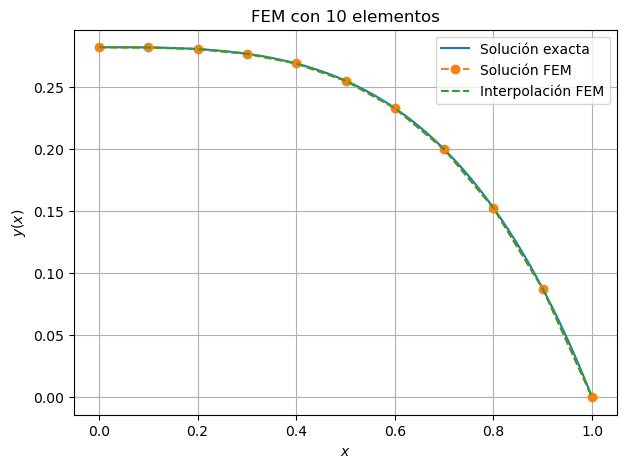

In [9]:
x_new = np. linspace(0,1,200)
y_new = np.interp(x_new, xi, sol)
plt.figure(figsize=(7,5))
plt.plot(x_new, exact(x_new), label="Solución exacta")
plt.plot(xi, sol, "o--", label="Solución FEM")
plt.plot(x_new, y_new, "--", label="Interpolación FEM")
plt.xlabel(r"$x$")
plt.ylabel(r"$y(x)$")
plt.title(f"FEM con {N-1} elementos")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
#error
y_ex_nodos = exact(xi)
error = np.abs(sol - y_ex_nodos)

for i in range(N):
    print(f"x = {xi[i]:.2f}, FEM = {sol[i]:.8f}, exacta = {y_ex_nodos[i]:.8f}, error = {error[i]:.2e}")

print("Error máximo:", np.max(error))

x = 0.00, FEM = 0.28171817, exacta = 0.28171817, error = 0.00e+00
x = 0.10, FEM = 0.28154292, exacta = 0.28154292, error = 1.67e-16
x = 0.20, FEM = 0.28024314, exacta = 0.28024314, error = 0.00e+00
x = 0.30, FEM = 0.27647814, exacta = 0.27647814, error = 0.00e+00
x = 0.40, FEM = 0.26863769, exacta = 0.26863769, error = 4.44e-16
x = 0.50, FEM = 0.25480008, exacta = 0.25480008, error = 2.78e-16
x = 0.60, FEM = 0.23268449, exacta = 0.23268449, error = 1.67e-16
x = 0.70, FEM = 0.19959669, exacta = 0.19959669, error = 8.33e-17
x = 0.80, FEM = 0.15236729, exacta = 0.15236729, error = 2.22e-16
x = 0.90, FEM = 0.08728159, exacta = 0.08728159, error = 5.13e-16
x = 1.00, FEM = 0.00000000, exacta = 0.00000000, error = 0.00e+00
Error máximo: 5.134781488891349e-16


In [ ]:
#scrip general para resolver la ecuación diferencial para distintos número de elementos

def resolver_FEM(N, a, b, ya, yb, f):
    h = (b-a)/(N-1)
    xi = np.zeros(N, float)

    for i in range(0, N):
        xi[i] =a + i*h

    A = np.zeros((N, N), float)

    for i in range(1, N):
        A[i-1, i-1] = A[i-1, i-1] + 1/h
        A[i-1, i] = A[i-1, i] - 1/h
        A[i, i-1] = A[i, i-1] - 1/h
        A[i, i] = A[i, i] + 1/h

    def lin1(x, x1, x2):
        return (x - x1)/(x2 - x1)

    def lin2(x, x1, x2):
        return (x2 - x)/(x2 - x1)

    def int1(minimo, maximo):
        return integrate.quad(lambda x: f(x)*lin1(x, minimo, maximo), minimo, maximo)[0]

    def int2(minimo, maximo):
        return integrate.quad(lambda x: f(x)*lin2(x, minimo, maximo), minimo, maximo)[0]

    b_vec = np.zeros(N, float)

    for i in range(1, N):
        b_vec[i-1] = b_vec[i-1] + int2(xi[i-1], xi[i])
        b_vec[i] = b_vec[i] + int1(xi[i-1], xi[i])

    for i in range(0, N):
        b_vec[i] = b_vec[i] - ya*A[i,0]
        b_vec[i] = b_vec[i] - yb*A[i,N-1]

    A[0,0] = 1
    A[0,1] = 0
    A[1,0] = 0

    A[N-1, N-1] = 1
    A[N-1, N-2] = 0
    A[N-2, N-1] = 0

    b_vec[0] = ya
    b_vec[N-1] = yb

    sol = la.solve(A, b_vec)

    return xi, sol

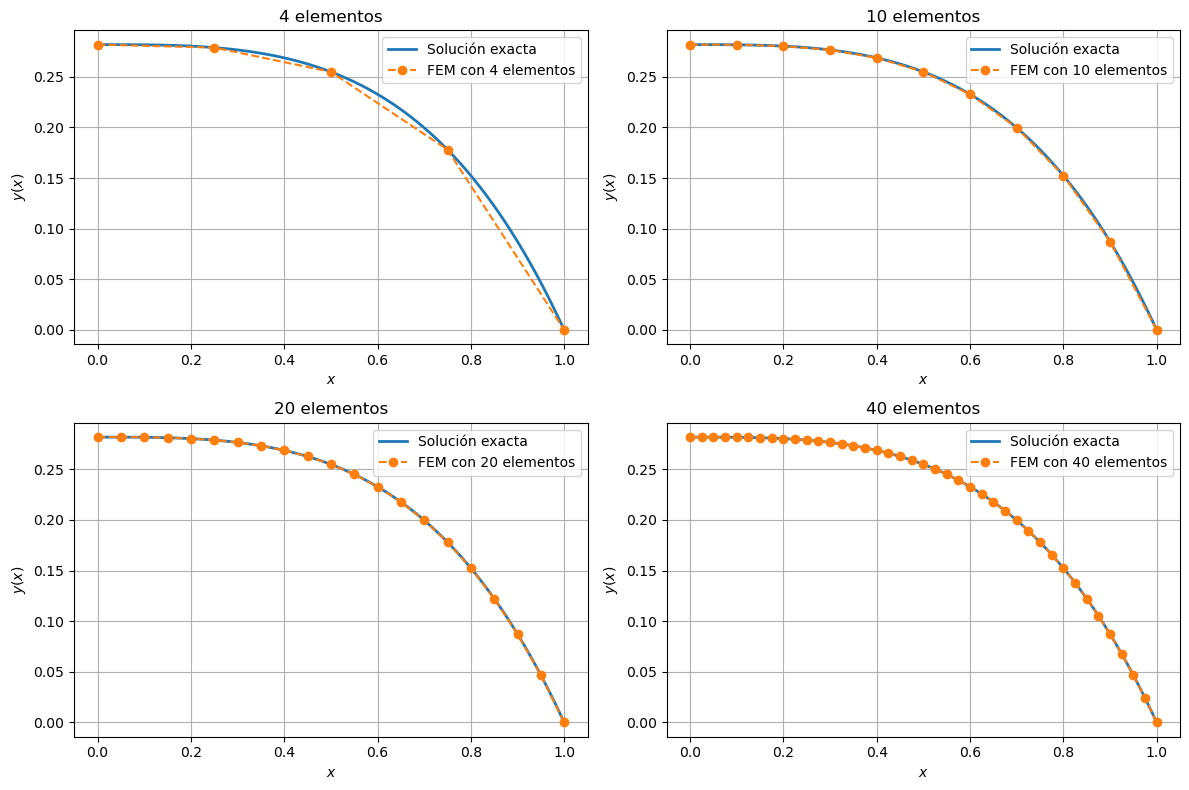

In [34]:
#Recordemos que N es el número de nodos por lo tanto N-1 es el número de elementos.
valores_N = [5, 11, 21, 41]
a_dom= 0
b_dom= 1
x_plot = np.linspace(0, 1, 300)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, N in zip(axes, valores_N):
    xi, sol = resolver_FEM(N, a_dom, b_dom, ya, yb, f)
    ax.plot(x_plot, exact(x_plot), label="Solución exacta", linewidth=2)
    ax.plot(xi, sol, "o--", label=f"FEM con {N-1} elementos")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y(x)$")
    ax.set_title(f"{N-1} elementos")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
#error de la solución Fem interpolada contra la solución exacta
x_plot = np.linspace(0, 1, 500)

for N in [5, 11, 21, 41]:
    xi, sol = resolver_FEM(N, a_dom, b_dom, ya, yb, f)

    y_interp = np.interp(x_plot, xi, sol)
    error_max = np.max(np.abs(y_interp - exact(x_plot)))

    print(f"Nodos = {N:3d}, elementos = {N-1:3d}, error máximo = {error_max:.6e}")

Nodos =   5, elementos =   4, error máximo = 1.650077e-02
Nodos =  11, elementos =  10, error máximo = 3.072294e-03
Nodos =  21, elementos =  20, error máximo = 8.072532e-04
Nodos =  41, elementos =  40, error máximo = 2.068801e-04


En este ejercicio se resolvió la ecuación diferencial $y'' = -xe^x$ usando el método de elementos finitos en una dimensión, para aplicar el método se reescribio la ecuación como: $-y'' = xe^x$ con este cambio se puede construir la matriz de rigidez y el vector del lado derecho y mediante integración numérica la solución obtenida con FEM se comparo con la solución analitica, observandose una buena corcondancia entre ambas, Además, el aumentar el número de elementos la aproximación mejora, lo cual confirma el comportamiento esperado del método.

# Ejercicio 2: Resolver la EDO.

$\frac{-d^2U}{dx^2}(x) = sin(\pi x)$ entre $0\leq x \leq 1$ con $U(0) = U(1) = 0$

Donde la solución exacta conocida es: $U(x) = \frac{1}{\pi ^2} sin(\pi x)$

In [40]:
N2 = 11 #número de nodos
h2 = 1/(N2-1)

xi2 = np.zeros(N2, float)
for i in range(0,N2):
    xi2[i] = i*h2

#solución exacta
def exact2(x):
    return (1/np.pi**2)*np.sin(np.pi*x)

A2 = np.zeros((N2,N2), float)

for i in range(1,N2):
    A2[i-1, i-1] = A2[i-1, i-1] + 1/h2
    A2[i-1, i] = A2[i-1, i] - 1/h2
    A2[i, i-1] = A2[i, i-1] - 1/h2
    A2[i,i] = A2[i,i] + 1/h2

def b1_elemento(x_izq, x_der, h2):
    return (np.cos(np.pi*x_izq)/np.pi 
            - (np.sin(np.pi*x_der) - np.sin(np.pi*x_izq))/(np.pi**2*h2))

def b2_elemento(x_izq, x_der, h2):
    return (-np.cos(np.pi*x_der)/np.pi 
            + (np.sin(np.pi*x_der) - np.sin(np.pi*x_izq))/(np.pi**2*h2))

b2= np.zeros(N2, float)

for i in range(1, N2):
    x_izq = xi2[i-1]
    x_der = xi2[i]
    h2_k = x_der - x_izq

    b2[i-1] = b2[i-1] + b1_elemento(x_izq, x_der, h2_k)
    b2[i] = b2[i] + b2_elemento(x_izq, x_der, h2_k)

#condiciones de frontera 
ua = 0
ub = 0

for i in range(0, N2):
    b2[i] = b2[i] - ua*A2[i,0]
    b2[i] = b2[i] - ub*A2[i,N2-1]

#condiciones de frontera en A
A2[0,0] = 1
A2[0,1] = 0
A2[1,0] = 0

A2[N2-1, N2-1] = 1
A2[N2-1, N2-2] = 0
A2[N2-2, N2-1] = 0

#condiciones de frontera en b
b2[0] = ua
b2[N2-1] = ub

#Resolver sistema
sol2 = la.solve(A2, b2)

sol2


array([0.        , 0.03130997, 0.0595551 , 0.08197056, 0.09636217,
       0.10132118, 0.09636217, 0.08197056, 0.0595551 , 0.03130997,
       0.        ])

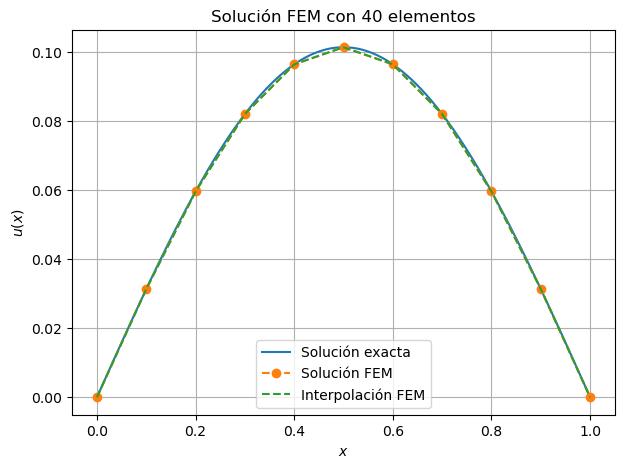

In [42]:
x_plot2 = np.linspace(0, 1, 300)
y_interp2 = np.interp(x_plot2, xi2, sol2)
plt.figure(figsize=(7,5))
plt.plot(x_plot2, exact2(x_plot2), label="Solución exacta")
plt.plot(xi2, sol2, "o--", label="Solución FEM")
plt.plot(x_plot2, y_interp2, "--", label="Interpolación FEM")
plt.xlabel(r"$x$")
plt.ylabel(r"$u(x)$")
plt.title(f"Solución FEM con {N-1} elementos")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
def resolver_FEM_seno(N2):
    h2 = 1/(N2-1)
    xi2 = np.zeros(N2, float)
    for i in range(0, N2):
        xi2[i] = i*h2

    A2 = np.zeros((N2, N2), float)

    for i in range(1, N2):
        A2[i-1, i-1] = A2[i-1, i-1] + 1/h2
        A2[i-1, i] = A2[i-1, i] - 1/h2
        A2[i, i-1] = A2[i, i-1] - 1/h2
        A2[i, i] = A2[i, i] + 1/h2

    b2 = np.zeros(N2, float)

    for i in range(1, N2):
        x_izq = xi2[i-1]
        x_der = xi2[i]
        h2_k = x_der - x_izq

        b2[i-1] = b2[i-1] + b1_elemento(x_izq, x_der, h2_k)
        b2[i]= b2[i] + b2_elemento(x_izq, x_der, h2_k)

    ua = 0
    ub = 0

    for i in range(0, N2):
        b2[i] = b2[i] - ua*A2[i,0]
        b2[i] = b2[i] - ub*A2[i,N2-1]

    A2[0,0] = 1
    A2[0,1] = 0
    A2[1,0] = 0

    A2[N2-1, N2-1] = 1
    A2[N2-1, N2-2] = 0
    A2[N2-2, N2-1] = 0

    b2[0] = ua
    b2[N2-1] = ub

    sol2 = la.solve(A2, b2)
    return xi2, sol2

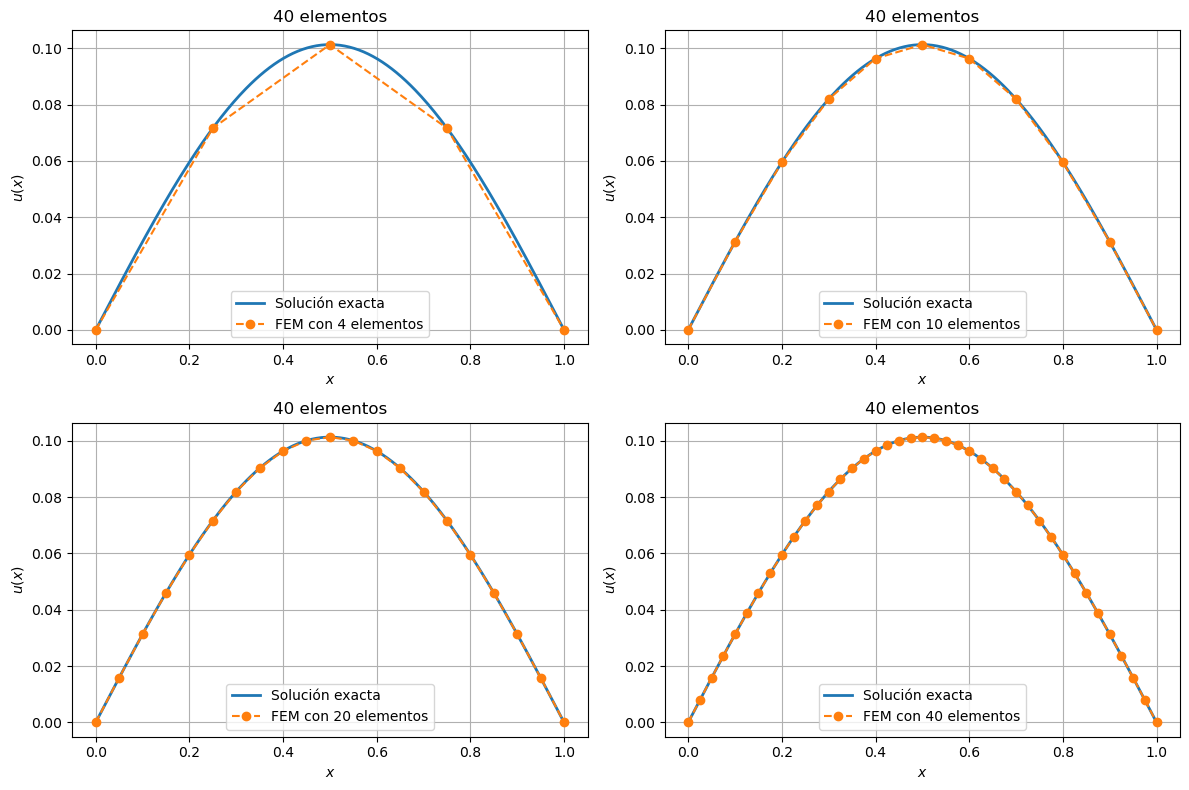

In [54]:
valores_N2 = [5, 11, 21, 41]
x_plot2 = np.linspace(0, 1, 300)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, N2 in zip(axes, valores_N2):
    xi2, sol2 = resolver_FEM_seno(N2)
    ax.plot(x_plot2, exact2(x_plot2), label="Solución exacta", linewidth=2)
    ax.plot(xi2, sol2, "o--", label=f"FEM con {N2-1} elementos")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$u(x)$")
    ax.set_title(f"{N-1} elementos")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [55]:
x_plot2 = np.linspace(0, 1, 500)
for N2 in [5, 11, 21, 41]:
    xi2, sol2 = resolver_FEM_seno(N2)
    u_interp = np.interp(x_plot2, xi2, sol2)
    error_max = np.max(np.abs(u_interp - exact2(x_plot2)))

    print(f"Nodos = {N:3d}, elementos = {N-1:3d}, error máximo = {error_max:.6e}")

Nodos =  41, elementos =  40, error máximo = 7.130669e-03
Nodos =  41, elementos =  40, error máximo = 1.231857e-03
Nodos =  41, elementos =  40, error máximo = 3.113740e-04
Nodos =  41, elementos =  40, error máximo = 7.791479e-05


En este ejercicio se resolvio la ecuación $-u'' = sin(\pi x)$ con condiciones de frontera homogneneas, la solución FEM se construyo usando la misma matriz de regidez del ejercicio 1 pero adaptando el vector de cargas según la función fuente $sin(\pi x)$. En este caso se uso la expresión analítica del vector elemental que se nos dio en la referencia del ejercicio. La solución numérica se comparo con la solución exacta $u(x) = \frac{1}{\pi ^2}sin(\pi x)$ y se observo que ambas también coinciden y que la solucion numérica mejora con el aumento del número de elementos.